In [99]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import FuncFormatter

In [77]:
visits = pd.read_csv("../data/raw/visitation_data_np_2015-2025.csv")
print(visits.shape)
print(visits.columns)
visits.head()

(8316, 35)
Index(['ParkName', 'UnitCode', 'ParkType', 'Region', 'State', 'Year', 'Month',
       'RecreationVisits', 'NonRecreationVisits', 'RecreationHours',
       'NonRecreationHours', 'ConcessionerLodging', 'ConcessionerCamping',
       'TentCampers', 'RVCampers', 'Backcountry',
       'NonRecreationOvernightStays', 'MiscellaneousOvernightStays',
       'ParkNameTotal', 'UnitCodeTotal', 'ParkTypeTotal', 'RegionTotal',
       'StateTotal', 'YearTotal', 'RecreationVisitsTotal',
       'NonRecreationVisitsTotal', 'RecreationHoursTotal',
       'NonRecreationHoursTotal', 'ConcessionerLodgingTotal',
       'ConcessionerCampingTotal', 'TentCampersTotal', 'RVCampersTotal',
       'BackcountryTotal', 'NonRecreationOvernightStaysTotal',
       'MiscellaneousOvernightStaysTotal'],
      dtype='object')


,ParkName,UnitCode,ParkType,Region,State,Year,Month,RecreationVisits,NonRecreationVisits,RecreationHours,...,NonRecreationVisitsTotal,RecreationHoursTotal,NonRecreationHoursTotal,ConcessionerLodgingTotal,ConcessionerCampingTotal,TentCampersTotal,RVCampersTotal,BackcountryTotal,NonRecreationOvernightStaysTotal,MiscellaneousOvernightStaysTotal
0,Acadia NP,ACAD,National Park,Northeast,ME,2015,1,"12,578",600,"83,017",...,"47,100","14,452,151","47,100",0,0,"135,000","32,094","1,233",0,"8,343"
1,Acadia NP,ACAD,National Park,Northeast,ME,2015,2,"10,626",600,"70,132",...,"47,100","14,452,151","47,100",0,0,"135,000","32,094","1,233",0,"8,343"
2,Acadia NP,ACAD,National Park,Northeast,ME,2015,3,"18,062",600,"119,207",...,"47,100","14,452,151","47,100",0,0,"135,000","32,094","1,233",0,"8,343"
3,Acadia NP,ACAD,National Park,Northeast,ME,2015,4,"63,214",600,"366,642",...,"47,100","14,452,151","47,100",0,0,"135,000","32,094","1,233",0,"8,343"
4,Acadia NP,ACAD,National Park,Northeast,ME,2015,5,"187,205","7,500","1,062,976",...,"47,100","14,452,151","47,100",0,0,"135,000","32,094","1,233",0,"8,343"


In [69]:
#drop total values
visits = visits.drop(columns=['ParkNameTotal', 'UnitCodeTotal',
 'ParkTypeTotal', 'RegionTotal', 'StateTotal', 'YearTotal', 'RecreationVisitsTotal', 'NonRecreationVisitsTotal','RecreationHoursTotal', 'NonRecreationHoursTotal',
 'ConcessionerLodgingTotal', 'ConcessionerCampingTotal', 'TentCampersTotal', 'RVCampersTotal', 'BackcountryTotal', 'NonRecreationOvernightStaysTotal', 'MiscellaneousOvernightStaysTotal'])
visits.columns

Index(['ParkName', 'UnitCode', 'ParkType', 'Region', 'State', 'Year', 'Month',
       'RecreationVisits', 'NonRecreationVisits', 'RecreationHours',
       'NonRecreationHours', 'ConcessionerLodging', 'ConcessionerCamping',
       'TentCampers', 'RVCampers', 'Backcountry',
       'NonRecreationOvernightStays', 'MiscellaneousOvernightStays'],
      dtype='object')

In [70]:
#cleaning column names
visits.columns = ['Park Name', 'Unit Code', 'Park Type', 'Region', 'State', 'Year', 'Month', 'Recreation Visits', 'Non Recreation Visits', 'Recreation Hours', 'Non Recreation Hours', 'Concessioner Lodging', 'Concessioner Camping', 'Tent Campers', 'RV Campers', 'Backcountry', 'Non Recreation Overnight Stays', 'Miscellaneous Overnight Stays']
visits.columns

Index(['Park Name', 'Unit Code', 'Park Type', 'Region', 'State', 'Year',
       'Month', 'Recreation Visits', 'Non Recreation Visits',
       'Recreation Hours', 'Non Recreation Hours', 'Concessioner Lodging',
       'Concessioner Camping', 'Tent Campers', 'RV Campers', 'Backcountry',
       'Non Recreation Overnight Stays', 'Miscellaneous Overnight Stays'],
      dtype='object')

In [72]:
cols = ['Recreation Visits', 'Non Recreation Hours',
        'Concessioner Lodging', 'Concessioner Camping',
        'Tent Campers', 'RV Campers', 'Backcountry', 'Non Recreation Visits',
        'Recreation Hours',
        'Non Recreation Overnight Stays',
        'Miscellaneous Overnight Stays']
#removing commas from numbers
for col in cols:
    visits[col] = visits[col].astype(str).str.replace(',', '', regex=False)

visits[cols] = visits[cols].astype(int)

visits.info()
visits.isnull().sum()
visits.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8316 entries, 0 to 8315
Data columns (total 18 columns):
 #   Column                          Non-Null Count  Dtype 
---  ------                          --------------  ----- 
 0   Park Name                       8316 non-null   object
 1   Unit Code                       8316 non-null   object
 2   Park Type                       8316 non-null   object
 3   Region                          8316 non-null   object
 4   State                           8316 non-null   object
 5   Year                            8316 non-null   int64 
 6   Month                           8316 non-null   int64 
 7   Recreation Visits               8316 non-null   int64 
 8   Non Recreation Visits           8316 non-null   int64 
 9   Recreation Hours                8316 non-null   int64 
 10  Non Recreation Hours            8316 non-null   int64 
 11  Concessioner Lodging            8316 non-null   int64 
 12  Concessioner Camping            8316 non-null   

,Park Name,Unit Code,Park Type,Region,State,Year,Month,Recreation Visits,Non Recreation Visits,Recreation Hours,Non Recreation Hours,Concessioner Lodging,Concessioner Camping,Tent Campers,RV Campers,Backcountry,Non Recreation Overnight Stays,Miscellaneous Overnight Stays
0,Acadia NP,ACAD,National Park,Northeast,ME,2015,1,12578,600,83017,600,0,0,0,0,0,0,0
1,Acadia NP,ACAD,National Park,Northeast,ME,2015,2,10626,600,70132,600,0,0,0,0,0,0,0
2,Acadia NP,ACAD,National Park,Northeast,ME,2015,3,18062,600,119207,600,0,0,0,0,0,0,0
3,Acadia NP,ACAD,National Park,Northeast,ME,2015,4,63214,600,366642,600,0,0,0,0,0,0,0
4,Acadia NP,ACAD,National Park,Northeast,ME,2015,5,187205,7500,1062976,7500,0,0,10248,1737,44,0,753


In [73]:
clean_visits = visits
clean_visits.to_csv('../data/clean/visitation_data_clean.csv', index=False)

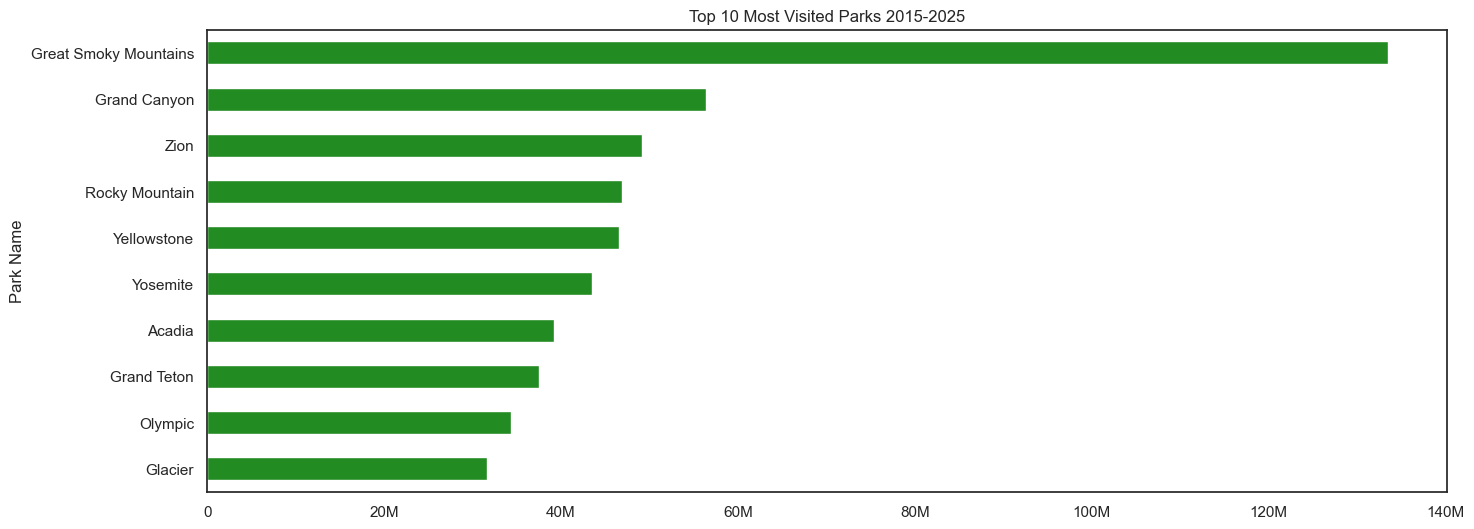

In [ ]:
#top 10 parks by visitation numbers
sns.set_theme(style="white", palette="Greens")
park_vis = clean_visits.groupby('Park Name')['Recreation Visits'].sum()
top_park_vis = park_vis.sort_values(ascending=False).head(10)
top_park_vis.index = top_park_vis.index.str.replace(' NP', '', regex=False)
plt.figure(figsize=(16,6))
top_park_vis.sort_values().plot(kind='barh', color ='forestgreen')
plt.title("Top 10 Most Visited Parks 2015-2025")
plt.xlabel("Total Recreational Visits")
ax = top_park_vis.sort_values().plot(kind='barh',color='forestgreen')
ax.xaxis.set_major_formatter(FuncFormatter(lambda x, pos: '0' if x == 0 else f'{x/1e6:.0f}M'))
plt.show()

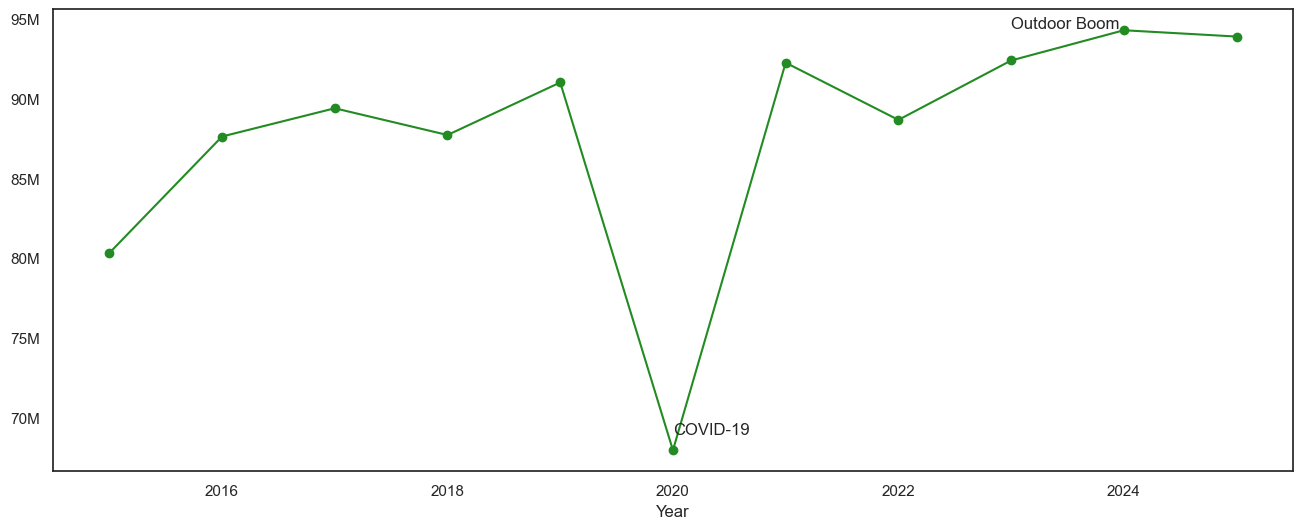

In [147]:
#Visitation Over Time
yearly_visits = clean_visits.groupby('Year')['Recreation Visits'].sum()
plt.figure(figsize=(16,6))
ax = yearly_visits.plot(kind='line', marker='o',color='forestgreen')
ax.annotate('COVID-19',xy=(2020, yearly_visits.loc[2020]),xytext=(2020, yearly_visits.loc[2020] +1_000_000))
ax.annotate('Outdoor Boom',xy=(2023, yearly_visits.loc[2023]),xytext=(2023, yearly_visits.loc[2023] +2_000_000))
ax.yaxis.set_major_formatter(FuncFormatter(lambda y, pos: '0' if y == 0 else f'{y/1e6:.0f}M'))

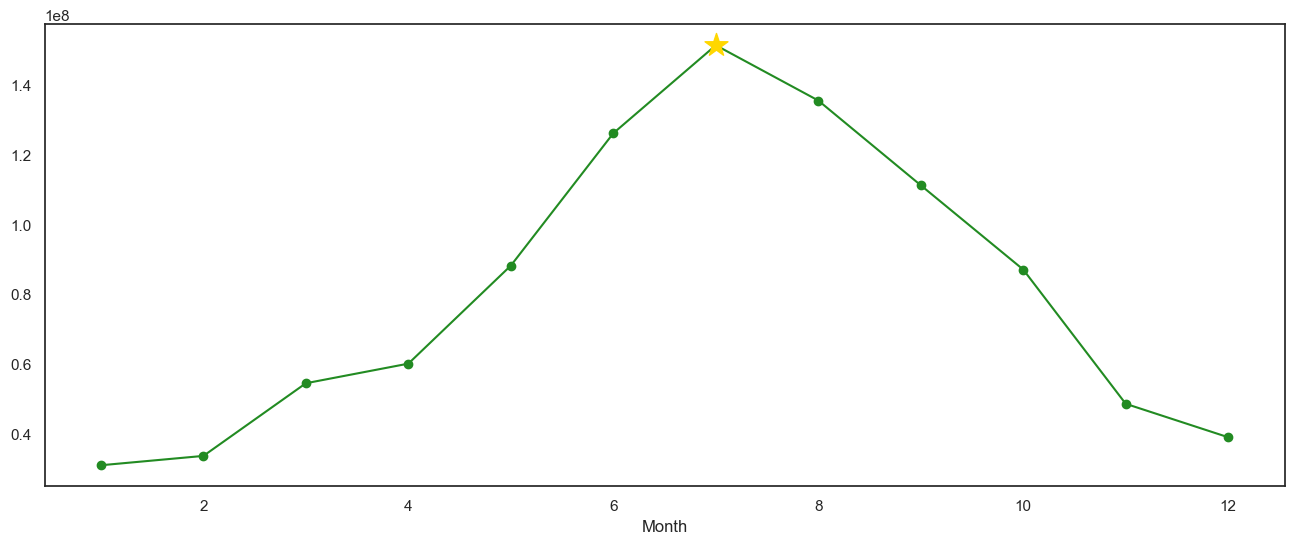

In [ ]:
#Monthly Visitation - Which month has the highest visitation?
monthly_visits = clean_visits.groupby('Month')['Recreation Visits'].sum()
plt.figure(figsize=(16,6))
monthly_visits.plot(kind='line', marker='o',color='forestgreen')
july_val = monthly_visits.loc[7]
plt.scatter(7,july_val,marker='*',s=300,color='gold',zorder=5) #star to depict that July is the most popular month to visit national parks

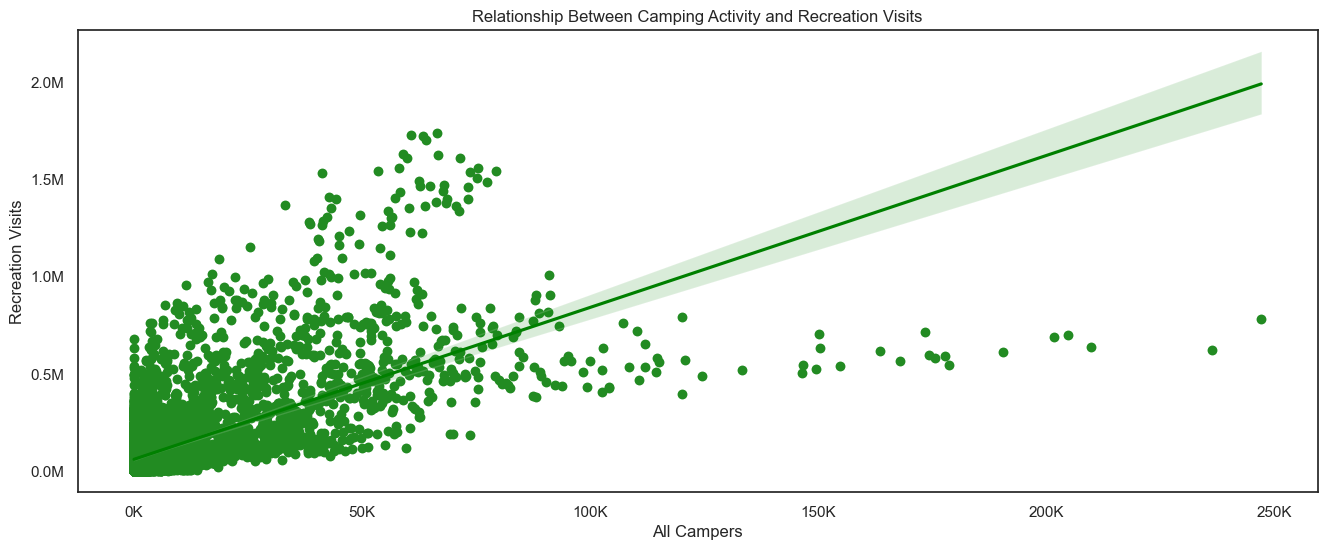

In [175]:
#do more visitors mean more campers?   
clean_visits['All Campers'] = clean_visits['RV Campers'] + clean_visits['Tent Campers'] + clean_visits['Backcountry']
plt.figure(figsize=(16,6))
plt.scatter(clean_visits['All Campers'], clean_visits['Recreation Visits'], color = 'forestgreen')
plt.title("Relationship Between Camping Activity and Recreation Visits")
plt.xlabel("Total Campers")
plt.ylabel("Recreation Visits")

sns.regplot(x='All Campers',y='Recreation Visits',data=clean_visits,scatter_kws={'alpha':0.3, 'color':'forestgreen'},line_kws={'color':'green'})

ax = plt.gca()
ax.xaxis.set_major_formatter(FuncFormatter(lambda x, pos: f'{x/1000:.0f}K'))
ax.yaxis.set_major_formatter(FuncFormatter(lambda y, pos: f'{y/1e6:.1f}M'))

<Figure size 1000x600 with 0 Axes>

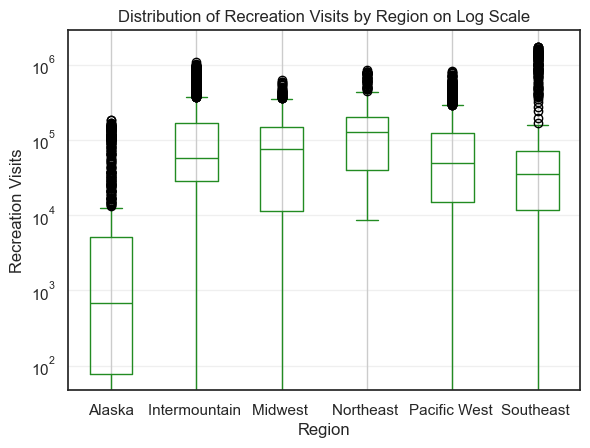

In [182]:
region_visits = clean_visits.groupby('Region')['Recreation Visits'].sum()
plt.figure(figsize=(10,6))
clean_visits.boxplot(column='Recreation Visits',by='Region', color ='forestgreen')

plt.yscale('log')
plt.title('Distribution of Recreation Visits by Region on Log Scale')
plt.suptitle('')
plt.xlabel('Region')
plt.ylabel('Recreation Visits')
plt.grid(axis='y', alpha=0.3)
plt.show()

In [183]:
clean_visits['Unit Code'].unique()

array(['ACAD', 'ARCH', 'BADL', 'BIBE', 'BISC', 'BLCA', 'BRCA', 'CANY',
       'CARE', 'CAVE', 'CHIS', 'CONG', 'CRLA', 'CUVA', 'DEVA', 'DENA',
       'DRTO', 'EVER', 'GAAR', 'JEFF', 'GLBA', 'GLAC', 'GRCA', 'GRTE',
       'GRBA', 'GRSA', 'GRSM', 'GUMO', 'HALE', 'HAVO', 'HOSP', 'INDU',
       'ISRO', 'JOTR', 'KATM', 'KEFJ', 'KICA', 'KOVA', 'LACL', 'LAVO',
       'MACA', 'MEVE', 'MORA', 'NPSA', 'NERI', 'NOCA', 'OLYM', 'PEFO',
       'PINN', 'REDW', 'ROMO', 'SAGU', 'SEQU', 'SHEN', 'THRO', 'VIIS',
       'VOYA', 'WHSA', 'WICA', 'WRST', 'YELL', 'YOSE', 'ZION'],
      dtype=object)

In [ ]:
parks = pd.read_csv("../data/raw/nps_parks.csv")
#pulling national parks from dataset
national_parks = parks[parks["designation"].str.contains("National Park", na=False)]
national_parks.columns = ['Park', 'State', 'Latitude', 'Longitude','Designation', 'Park Code', 'Activities', 'Entrance Fees']

#Dropping Designation column because we know that all data is from a national park
national_parks = national_parks.drop(columns = ['Designation'] )
print(national_parks.columns)

#combining data
clean_visits['Unit Code'] = clean_visits['Unit Code'].str.lower()
combined = pd.merge(clean_visits, national_parks, left_on = 'Unit Code', right_on='Park Code', how='inner')
combined.columns 

Index(['Park', 'State', 'Latitude', 'Longitude', 'Park Code', 'Activities',
       'Entrance Fees'],
      dtype='object')


Index(['Park Name', 'Unit Code', 'Park Type', 'Region', 'State_x', 'Year',
       'Month', 'Recreation Visits', 'Non Recreation Visits',
       'Recreation Hours', 'Non Recreation Hours', 'Concessioner Lodging',
       'Concessioner Camping', 'Tent Campers', 'RV Campers', 'Backcountry',
       'Non Recreation Overnight Stays', 'Miscellaneous Overnight Stays',
       'All Campers', 'Park', 'State_y', 'Latitude', 'Longitude', 'Park Code',
       'Activities', 'Entrance Fees'],
      dtype='object')